# E-tivity 1 (27/01/25 - 09/02/25)

* Pierce Currid

* 23260092

## Anomaly Detection

### Context
We have a mystery dataset. There are 9 explanatory variables and one response variable. The response variable is the last column and indicates if the sample is anomalous (=1, valid =0). The dataset is provided "data.csv".

Of course in this case we could use supervised learning to generate a model and detect anomalies in new data. However the focus is on autoencoders, anomaly detection is just one of the potential uses for autoencoders.

So we are going to pretend that we do not know which data are anomalous but we do know that the anomaly rate is small. Use an autoencoder to detect anomalies in the data. The correctness of the model can of course be checked.

### Guidelines

The e-tivity is split into four tasks. The first three are "group" excersises, in that you post the solutions to Tasks 1-3 to a site. This will allow the members of your group to send you feedback (via the forums) so you can improve your submission. The final task is an individual task and together with the other tasks, should be uploaded to the Group Locker.

Marks will be deducted if task 4 is uploaded in contravention of instructions. Also if the the final submission is not a single notebook with tasks 1-4 and with correct identification or filename.

Grading guidelines: the scores for each task are additive. Below is a link to the E-tivity rubrics.

https://learn.ul.ie/d2l/lp/rubrics/preview.d2l?ou=49284&rubricId=2620&originTool=quicklinks



## Problem

If you train even a modest feed forward network via supervised learning you can get extremely good recall and precision, despite the unbalanced dataset. However in this e-tivity you will determining the anomalies by using an autoencoder. That is you will **not** be using the Anom flag to guide the training.

The mystery dataset is available from Brightspace, download the csv file and use it as the input data.

### Tasks 1-3 (complete by Sunday 02/02/25)

The initial implementation of the tasks are to be uploaded to the locker on which the other group members can comment. The forum activity will form part of the overall mark for the e-tivity.

**Loading the dataset**

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits import mplot3d

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import RobustScaler

from sklearn.decomposition import PCA, FactorAnalysis

from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.layers import UpSampling2D, Reshape
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adagrad
from tensorflow.keras import backend as K
from tensorflow.keras.callbacks import EarlyStopping


In [3]:
#if using google colab
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [4]:
#import the file
mystery_data = pd.read_csv('/content/gdrive/My Drive/AI UL/2024-25/CS5004/assignments/data.csv')

**Task 1: data preprocessing**

Explain any preprocessing steps you take and also how you have selected the training and test sets. Remember we do not know which samples are anomalous only that there are a small number of them compared to the total sample size.


In [5]:
#super quick analysis of the data - feature/sample counts
print(f"The dataset contains {mystery_data.shape[0]} features and {mystery_data.shape[1]} samples")

The dataset contains 49097 features and 10 samples


In [6]:
#check for any missing values
mystery_data.isnull().sum()

,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0
Anom,0


In [7]:
#check the head and tail
explanatory_cols = ['V1', 'V2','V3','V4','V5','V6','V7','V8','V9',]
mystery_data.loc[:,explanatory_cols].head(5)

,V1,V2,V3,V4,V5,V6,V7,V8,V9
0,50,21,77,0,28,0,27,48,22
1,53,0,82,0,52,-5,29,30,2
2,37,0,76,0,28,18,40,48,8
3,37,0,79,0,34,-26,43,46,2
4,85,0,88,-4,6,1,3,83,80


In [8]:
#check the head and tail
mystery_data.loc[:,explanatory_cols].tail(5)

,V1,V2,V3,V4,V5,V6,V7,V8,V9
49092,39,-2,80,-4,38,0,41,41,0
49093,43,0,81,1,42,-9,37,39,2
49094,49,0,87,0,46,-12,38,41,2
49095,80,0,84,0,-36,-29,4,120,116
49096,37,0,103,0,18,-16,66,85,20


In [9]:
#briefly checking the counts for Anom
mystery_data['Anom'].value_counts()

,count
Anom,
0,45586
1,3511


In [10]:
mystery_data[explanatory_cols].select_dtypes(include=np.number).describe()

,V1,V2,V3,V4,V5,V6,V7,V8,V9
count,49097.000000,49097.000000,49097.000000,49097.000000,49097.000000,49097.000000,49097.000000,49097.000000,49097.000000
mean,46.932399,-0.063955,85.123124,0.213231,36.871784,2.160030,38.200725,48.288592,10.261930
std,12.875159,84.674481,8.877517,37.579171,19.963113,218.324964,13.446306,20.572064,23.751024
min,27.000000,-4821.000000,21.000000,-3939.000000,-188.000000,-26739.000000,-48.000000,-353.000000,-356.000000
25%,37.000000,0.000000,79.000000,0.000000,30.000000,-4.000000,33.000000,35.000000,0.000000
50%,44.000000,0.000000,83.000000,0.000000,42.000000,0.000000,39.000000,41.000000,2.000000
75%,50.000000,0.000000,88.000000,0.000000,46.000000,5.000000,43.000000,55.000000,6.000000
max,126.000000,5075.000000,149.000000,3830.000000,436.000000,15164.000000,105.000000,270.000000,266.000000


We can see that from a preprocessing pov, the data is all numeric and there are no missing values either, which removes the need for any encoding or needing any strategy for imputation. In terms of distributions, will use plotting to see what normalisation might be needed in terms of outliers as well as a confusion matrix to see levels of correlation. This might help identify what variables are strongly correlated and will help with dimension reductions





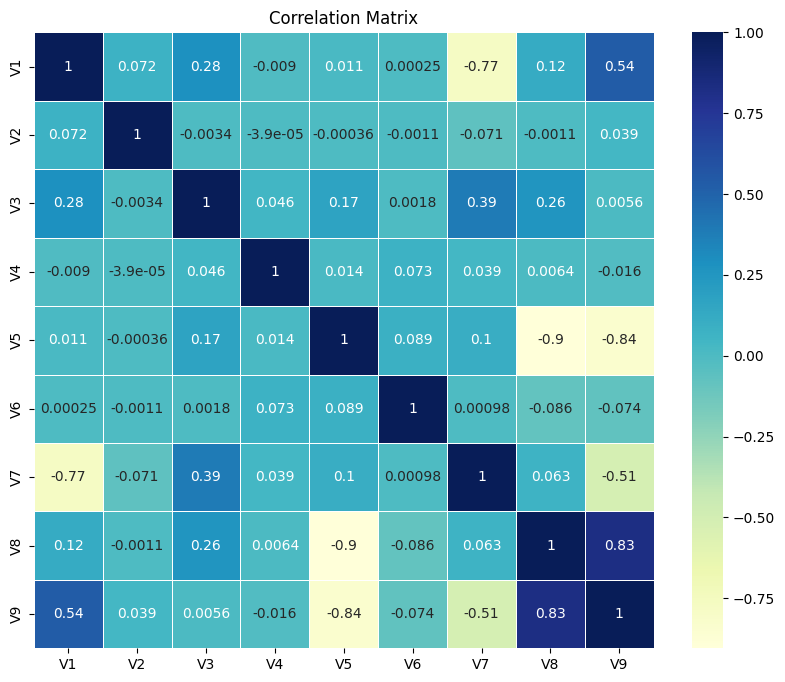

In [11]:
correlation = mystery_data[explanatory_cols].corr()
plt.figure(figsize=(10,8))
sns.heatmap(correlation, annot=True, linewidths=0.5, cmap="YlGnBu")

plt.title('Correlation Matrix')

plt.show()

Some initial thoughts on correlation:


2. Features V8 & V9 are quite closely pairwise correlated. Of course, it would be ideal to remove the one that is less closely correlated to the response variable, but given we're not using supervised learning here, I'm not sure that should be done.
3.   Features V1 & V9 are correlated also, but to a lesser degree than V8 & V9
4. Features V3 & V7 have a reasonable correlation






Based on the distribution of values across the dimensions, here are some box plots to highlight outliers that might skew training of the model. As we can see below, all of the features have outliers, so we will have to scale the data.

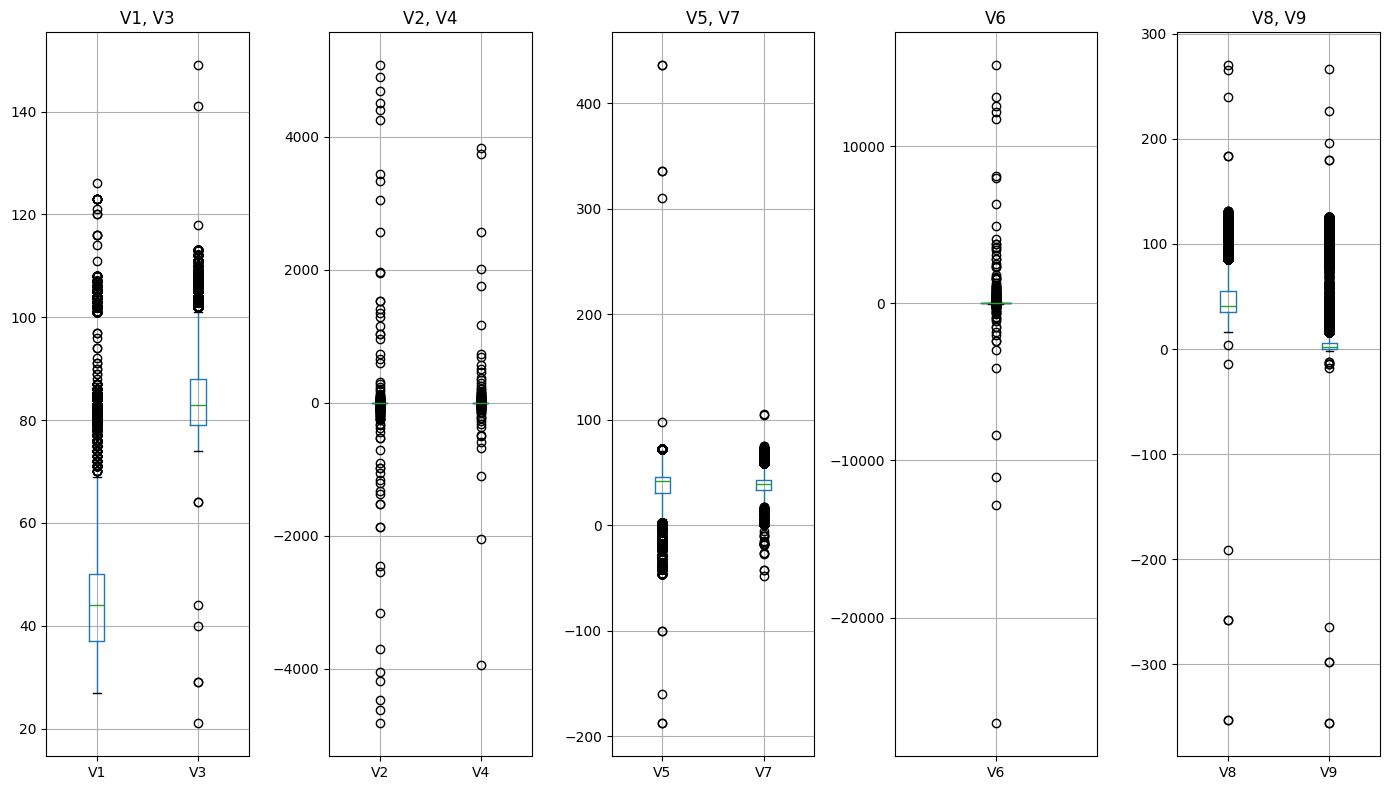

In [12]:
#visualisation of feature distribution, which may unduly impact any dimension reduction techniques
fig, axs = plt.subplots(nrows=1, ncols=5, figsize=(14, 8))

mystery_data[explanatory_cols].boxplot(column=['V1','V3'], ax=axs[0])
axs[0].set_title('V1, V3')

mystery_data[explanatory_cols].boxplot(column=['V2','V4'], ax=axs[1])
axs[1].set_title('V2, V4')

mystery_data[explanatory_cols].boxplot(column=['V5','V7'], ax=axs[2])
axs[2].set_title('V5, V7')

mystery_data[explanatory_cols].boxplot(column=['V6'], ax=axs[3])
axs[3].set_title('V6')

mystery_data[explanatory_cols].boxplot(column=['V8','V9'], ax=axs[4])
axs[4].set_title('V8, V9')

plt.tight_layout()
plt.show()

In [13]:
#making a copy before the scaling and splits
scaled_mystery_data = mystery_data.copy()

Scaling the data. Given the outliers within V6 (std of 218) and to a lesser degree V2 (std of 84.67) which we can see in the 'descibe()' output above, I'll use RobustScaler for V6 as it handles outliers better than StandardScaler. I'll use Standardscaler for the rest of the features.

In [14]:
extreme_outlier_list = ['V6']
standard_outlier_list = ['V1', 'V2', 'V3', 'V4', 'V5', 'V7', 'V9']

In [15]:
# Scaling most of the data with a StandardScaler() instance -scaling the standard_outlier_list
scaler = StandardScaler()
scaler.fit(scaled_mystery_data[standard_outlier_list])
standard_scaled_data = scaler.transform(scaled_mystery_data[standard_outlier_list])

In [16]:
scaled_mystery_data[standard_outlier_list] = standard_scaled_data

In [17]:
#drop anom
scaled_mystery_data.drop(columns=['Anom'], inplace=True)

In [18]:
scaled_mystery_data.describe()

,V1,V2,V3,V4,V5,V6,V7,V8,V9
count,4.909700e+04,4.909700e+04,4.909700e+04,4.909700e+04,4.909700e+04,49097.000000,4.909700e+04,49097.000000,4.909700e+04
mean,1.515242e-16,2.315556e-18,-6.136223e-17,4.052222e-18,1.856786e-16,2.160030,1.186722e-17,48.288592,-2.720778e-17
std,1.000010e+00,1.000010e+00,1.000010e+00,1.000010e+00,1.000010e+00,218.324964,1.000010e+00,20.572064,1.000010e+00
min,-1.548144e+00,-5.693551e+01,-7.223166e+00,-1.048254e+02,-1.126448e+01,-26739.000000,-6.410802e+00,-353.000000,-1.542105e+01
25%,-7.714468e-01,7.553123e-04,-6.897408e-01,-5.674237e-03,-3.442276e-01,-4.000000,-3.867812e-01,35.000000,-4.320671e-01
50%,-2.277587e-01,7.553123e-04,-2.391598e-01,-5.674237e-03,2.568872e-01,0.000000,5.944258e-02,41.000000,-3.478593e-01
75%,2.382597e-01,7.553123e-04,3.240665e-01,-5.674237e-03,4.572588e-01,5.000000,3.569251e-01,55.000000,-1.794438e-01
max,6.141159e+00,5.993678e+01,7.195427e+00,1.019135e+02,1.999349e+01,15164.000000,4.967904e+00,270.000000,1.076756e+01


In [19]:
# Scaling the remainder of the data with a RobustScaler() instance
robust_scaler = RobustScaler()
extreme_scaled_data = robust_scaler.fit_transform(scaled_mystery_data[extreme_outlier_list])

In [20]:
#scaled_mystery_data['V2'] = extreme_scaled_data[:,0]

In [21]:
scaled_mystery_data['V6'] = extreme_scaled_data[:,0]

In [22]:
scaled_mystery_data.describe()

,V1,V2,V3,V4,V5,V6,V7,V8,V9
count,4.909700e+04,4.909700e+04,4.909700e+04,4.909700e+04,4.909700e+04,49097.000000,4.909700e+04,49097.000000,4.909700e+04
mean,1.515242e-16,2.315556e-18,-6.136223e-17,4.052222e-18,1.856786e-16,0.240003,1.186722e-17,48.288592,-2.720778e-17
std,1.000010e+00,1.000010e+00,1.000010e+00,1.000010e+00,1.000010e+00,24.258329,1.000010e+00,20.572064,1.000010e+00
min,-1.548144e+00,-5.693551e+01,-7.223166e+00,-1.048254e+02,-1.126448e+01,-2971.000000,-6.410802e+00,-353.000000,-1.542105e+01
25%,-7.714468e-01,7.553123e-04,-6.897408e-01,-5.674237e-03,-3.442276e-01,-0.444444,-3.867812e-01,35.000000,-4.320671e-01
50%,-2.277587e-01,7.553123e-04,-2.391598e-01,-5.674237e-03,2.568872e-01,0.000000,5.944258e-02,41.000000,-3.478593e-01
75%,2.382597e-01,7.553123e-04,3.240665e-01,-5.674237e-03,4.572588e-01,0.555556,3.569251e-01,55.000000,-1.794438e-01
max,6.141159e+00,5.993678e+01,7.195427e+00,1.019135e+02,1.999349e+01,1684.888889,4.967904e+00,270.000000,1.076756e+01


As we can see, the range has been reduced. One thing to note is that V2 does not appear to have been scaled. Need to revisit this

In [23]:
scaled_mystery_data_for_modeling = scaled_mystery_data.copy()

In [24]:
scaled_mystery_data_for_modeling.shape

(49097, 9)

In [25]:
# Splitting the data for training purposes, going with an 80/20 training/testing split
X_train, X_test, y_train, y_test = train_test_split(scaled_mystery_data_for_modeling,mystery_data['Anom'] , test_size=0.2, random_state=42)



---



**Task 2: model generation and training**

Generate a suitable autoencoder model, the only restriction is that there should be only 2 latent variables. Train the model to a satistifactory result. Be aware that it will be much harder to achieve the sort of result you can get from a supervised learning model.

**Hint**: it should not take longer than a 1000 epochs to train. However it may be difficult to train. Use different optimizers, topologies and/or weight initialisations to get convergence. Remember that achieving a perfect error means that the model will also be good at reconstructing anomalies.


use reconstruction error
scaling -

choice of activation function for nn layers: no need to bother too much tbh
important is the layer that gives encoded variables?
important is the output layer




In [47]:
#https://keras.io/api/models/model_training_apis/ - useful resources for syntax etc
#setting input & latent dimension to 2
input_dim = scaled_mystery_data_for_modeling.shape[1]
latent_dim = 2

#defining the encoder topology
input_layer = Input(shape=(input_dim,))
encoder = Dense(64, activation='relu')(input_layer)
encoder = Dense(32, activation='relu')(encoder)

#defining the latent space, using the request bottleneck dimension
latent_space = Dense(latent_dim, activation='linear')(encoder)

#instansiate the encoder model
encoder_model= Model(input_layer, latent_space, name = 'encoder_model')

#defining the decoder topology
decoder = Dense(32, activation='relu')(latent_space)
decoder = Dense(64, activation='relu')(decoder)
output_layer = Dense(input_dim, activation='linear')(decoder)

decoder_model = Model(latent_space, output_layer, name = 'decoder_model')

In [48]:
encoder_model.summary()

Model: "encoder_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)           │ (None, 9)                   │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_12 (Dense)                     │ (None, 64)                  │             640 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_13 (Dense)                     │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_14 (Dense)                     │ (None, 2)                   │              66 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,786 (10.88 KB)

 Trainable params: 2,786 (10.88 KB)

 Non-trainable params: 0 (0.00 B)

In [40]:
decoder_model.summary()

Model: "decoder_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ keras_tensor_12CLONE (InputLayer)    │ (None, 2)                   │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_9 (Dense)                      │ (None, 32)                  │              96 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_10 (Dense)                     │ (None, 64)                  │           2,112 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_11 (Dense)                     │ (None, 9)                   │             585 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,793 (10.91 KB)

 Trainable params: 2,793 (10.91 KB)

 Non-trainable params: 0 (0.00 B)

In [49]:
#create instance of the autoencoder model
ae = Model(input_layer, output_layer, name = 'autoencoder_model')
ae.summary()

Model: "autoencoder_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)           │ (None, 9)                   │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_12 (Dense)                     │ (None, 64)                  │             640 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_13 (Dense)                     │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_14 (Dense)                     │ (None, 2)                   │              66 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_15 (Dense)                     │ (None, 32)                  │              96 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_16 (Dense)                     │ (None, 64)                  │           2,112 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_17 (Dense)                     │ (None, 9)                   │             585 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 5,579 (21.79 KB)

 Trainable params: 5,579 (21.79 KB)

 Non-trainable params: 0 (0.00 B)

In [50]:
#optimiser
optimiser = Adagrad(learning_rate=0.0012)

#compile the model
ae.compile(optimizer=optimiser, loss='mse', metrics=['accuracy'])

In [51]:
#early stopping
earlystopper = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1)

In [52]:
#train the model
ae_training_record = ae.fit(X_train, X_train, epochs=700, batch_size=50, validation_data=(X_test, X_test), validation_split=0.2, callbacks=earlystopper)

Epoch 1/700
786/786 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9594 - loss: 145.1481 - val_accuracy: 0.9987 - val_loss: 53.3106
Epoch 2/700
786/786 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9989 - loss: 57.1247 - val_accuracy: 0.9987 - val_loss: 51.8794
Epoch 3/700
786/786 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9984 - loss: 51.3789 - val_accuracy: 0.9987 - val_loss: 50.5872
Epoch 4/700
786/786 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9988 - loss: 84.9319 - val_accuracy: 0.9987 - val_loss: 49.0525
Epoch 5/700
786/786 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9989 - loss: 65.0625 - val_accuracy: 0.9987 - val_loss: 47.5115
Epoch 6/700
786/786 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9989 - loss: 71.8795 - val_accuracy: 0.9987 - val_loss: 45.7949
Epoch 7/700
786/786 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9988 - loss: 71.1559 - val_accuracy: 0.9988 - val_loss: 44.1425
Epoch 8/700
786/786 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9991 - loss: 10

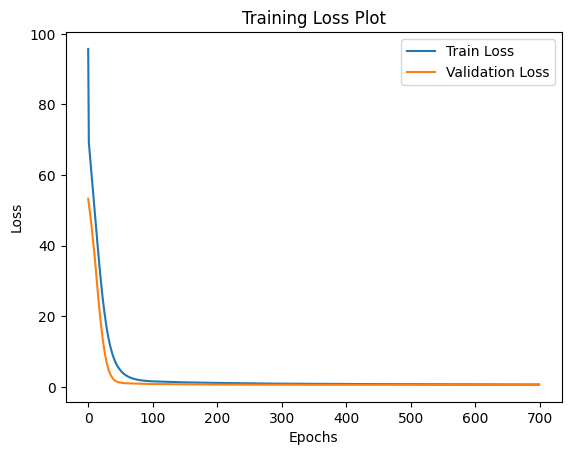

In [53]:
#plotting the training and val loss
plt.plot(ae_training_record.history['loss'], label='Train Loss')
plt.plot(ae_training_record.history['val_loss'], label='Validation Loss')

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.title("Training Loss Plot")
plt.show()

Adding a Learning Rate to the optimiser and stretching out the Epochs helped with smoother losses. The model is overfitted given the high accuracy validation accuracy rates however. Will add a little regularisation here too  




---



**Task 3: anomaly detection**

From the histogram of the reconstruction error decide what the cutoff should be applied to distinguish anomalies from valid samples, given that the anomaly rate is ~7%.

### Post (complete by Sunday 02/02/25)

Once you have an implemntation however rough, use the forums/topics to advertise the fact. The purpose is to get feedback from others in the group, so if you have only a basic outline then you may get ideas about how to proceed and also examples from others in your group.

No posts should refer to Task 4.

### Respond (complete by Wednesday 05/02/24)

If you feel you can provide useful advise then respond to another member of the group through the appropriate forum. Responses should be respectful and offer some sort of advise. Try and avoid clogging the forums with support or thank you messages.

In reviewing others code you will discover different ways to tackle the same problem. It is acceptable to copy parts of others code. However whole scale copying from another notebook is not acceptable.

If you stick to the deadline then it will allow yourself and others to have enough time to implement suggestions. From the Schedule you can see that this is not a hard deadline.

The posts on the forum/topic associated with this e-tivity are graded. Below is a link to the rubrics.

https://learn.ul.ie/d2l/lp/rubrics/preview.d2l?ou=49284&rubricId=2620&originTool=quicklinks

### Task 4: VAE (completed by Sunday 09/02/24)

This task is a individual task and should **not** to be uploaded to the Group Locker. No direct support should be given via the forums. Marks will be deducted if the instructions are not followed (see rubrics). This part should be uploaded directly to Brightpsace.

Change the network to be a VAE. Again determine the optimal cutoff and plot the latent variables. Check how good the cutoffs were by constructing a confusion matrix or generating a classification report. Obviously for this task you need to use the Anom column.

**Hint** you can use the model topology from the AE (with the obvious modifications). I found that I had a good model (almost as good and the supervised learning model) when the KL divergence was small. You can print out both the KL divergence and reconstruction loss for each epoch. It can be tricky to train these type of models, so do not be surprised if you do not get a stellar result. What is more important is that you have the correct code to implement the VAE.

### Final Submission (complete by Sunday 09/02/24)

Submit Tasks 1-4 in a single notebook this before the deadline on Sunday.


In [ ]:
## Add additional code cells to implememt the tasks stated above

## Reflection

There are no specific marks allocated for a reflection. However due consideration will be given if pertinent comments or valuable insights are made.